# Women's Model

This notebook makes the machine learning model. Remember to uncomment the last cell if you would like to save the model. 

### Data Setup

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 100)

df_mod = pd.read_parquet(r'..\data\preprocessed\womens_model_data\model_data.parquet')

df_mod

,Season,Result,Team A ID,Team A,Team B ID,Team B,Round,Location,Seed,Head to Head,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Mu,OS Rating,Team A Efficiency Margin,Team B Efficiency Margin
0,2012,1,3116,Arkansas,3173,Dayton,1,0,-5,NaN,-0.133288,-1.0,-0.750000,-0.058519,-0.055132,-0.046267,0.030005,0.005625,-0.024380,-8.312479,-1.395719,-0.848218,0.242118,0.212113
1,2012,1,3163,Connecticut,3341,Prairie View,1,0,-15,NaN,1.433520,4.0,2.750000,0.599396,0.587873,5.533340,0.683283,0.335346,-0.347937,1.164885,30.158018,30.046412,0.612579,-0.070705
2,2012,1,3177,DePaul,3140,BYU,1,0,-3,NaN,-0.333089,3.0,1.000000,0.116604,0.152977,0.942105,0.021541,0.069822,0.048281,2.527211,-3.043846,-2.413117,0.243769,0.222228
3,2012,1,3211,Gonzaga,3353,Rutgers,1,0,5,NaN,NaN,2.0,1.000000,0.046283,-0.025164,-0.565226,-0.048145,0.054367,0.102513,4.992007,3.506069,2.932589,0.216886,0.265031
4,2012,1,3243,Kansas St,3343,Princeton,1,0,-1,NaN,-0.653105,0.0,-0.250000,-0.023129,0.142977,0.166964,-0.066541,-0.049703,0.016838,-6.785140,-5.096065,-3.479339,0.203945,0.270486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,2024,-1,3425,USC,3163,Connecticut,4,0,-2,NaN,0.481418,-2.0,-4.333333,-0.157742,-0.286640,-0.166886,-0.130033,-0.062637,0.067396,-2.007100,-0.349031,-0.542839,0.373978,0.504011
1508,2024,-1,3261,LSU,3234,Iowa,4,0,2,NaN,0.228265,1.0,-0.666667,0.033278,-0.057085,-0.519727,-0.045249,-0.100185,-0.054936,-0.004142,-1.030708,-0.630969,0.402188,0.447437
1509,2024,-1,3163,Connecticut,3234,Iowa,5,0,2,NaN,0.071684,-3.0,1.000000,0.019989,0.140849,0.181251,0.056574,-0.058381,-0.114955,-4.357594,0.057720,0.323102,0.504011,0.447437
1510,2024,-1,3301,NC State,3376,South Carolina,5,0,2,NaN,-0.379131,-4.0,-3.000000,-0.272947,-0.153657,-2.108665,-0.186511,-0.120974,0.065538,-2.295430,-12.321040,-11.483347,0.354143,0.540655


In [2]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Season                           1512 non-null   int64  
 1   Result                           1512 non-null   int64  
 2   Team A ID                        1512 non-null   int64  
 3   Team A                           1512 non-null   object 
 4   Team B ID                        1512 non-null   int64  
 5   Team B                           1512 non-null   object 
 6   Round                            1512 non-null   int64  
 7   Location                         1512 non-null   int64  
 8   Seed                             1512 non-null   int64  
 9   Head to Head                     204 non-null    float64
 10  Common Opps                      1152 non-null   float64
 11  Past Year Tournament Result      1386 non-null   float64
 12  Past 4 Years Tournam

Remove features that don't seem to be helping model

In [3]:
df_mod.drop(
    columns=[
        'Round',
        'Mu',
        'Adjusted Tempo',
        'Location',
        'Common Opps',
    ],
    inplace=True,
)

In [4]:
# df_mod.drop(
#     columns=[
#         # 'Team B Efficiency Margin',
#         'ADJEM',
#         'WAB',
#         'Team TOR',
#         # 'Common Opps',
#         # 'Past Year Tournament Result',
#         # 'Past 4 Years Tournament Results',
#         'Team B ADJOE Team A ADJDE',
#         'Team A ADJOE Team B ADJDE',
#         # 'Opponent FTR',
#         # 'Team FTR',
#         'Team ORBR',
#         # 'Opponent EFG%',
#         'ADJ T.',
#         # 'Team EFG%',
#         'Team Win%',
#         'WIN%',
#         'ADJOE',
#         'ADJDE',
#         'Adjusted Tempo',
#         'Location',
#         'BARTHAG',
#         'Round',

#         # 'Opponent FTR',

#         'Mu',

#         'Starters',

#         'Team EFG%',
#         'Opponent EFG%',
#         'Team FTR',
#         'Opponent FTR',

#         'Team A Offense Team B Defense',
#         'Team B Offense Team A Defense',

#         'Common Opps',

#         # 'Past Year Tournament Result',
#         # 'Past 4 Years Tournament Results',
#     ],
#     inplace=True,
# )

Get monotonic constraints

In [5]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Seed                              -0.62
Adjusted Defense                  -0.57
Team B Efficiency Margin          -0.49
Season                             0.00
Team A ID                          0.00
Team B ID                         -0.00
Team A Efficiency Margin           0.49
Past 4 Years Tournament Results    0.51
Past Year Tournament Result        0.52
Past 4 Years Efficiency Margin     0.57
Adjusted Offense                   0.59
OS Rating                          0.59
Past Year Efficiency Margin        0.60
Rating                             0.62
Efficiency Margin                  0.63
Head to Head                       0.83
Result                             1.00
Name: Result, dtype: float64

In [6]:
# df_mod = df_mod.loc[:, ['Season', 'Team A ID', 'Team A', 'Team B ID', 'Team B'] + list(correlations.loc[correlations.abs() >= 0.00].index)]

# df_mod

In [7]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Seed                              -0.62
Adjusted Defense                  -0.57
Team B Efficiency Margin          -0.49
Season                             0.00
Team A ID                          0.00
Team B ID                         -0.00
Team A Efficiency Margin           0.49
Past 4 Years Tournament Results    0.51
Past Year Tournament Result        0.52
Past 4 Years Efficiency Margin     0.57
Adjusted Offense                   0.59
OS Rating                          0.59
Past Year Efficiency Margin        0.60
Rating                             0.62
Efficiency Margin                  0.63
Head to Head                       0.83
Result                             1.00
Name: Result, dtype: float64

In [8]:
correlations_threshold = 0.10

correlations.loc[correlations.abs() < correlations_threshold].round(2)

Season       0.0
Team A ID    0.0
Team B ID   -0.0
Name: Result, dtype: float64

In [9]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > correlations_threshold], 
    [1 for _ in range((correlations > correlations_threshold).sum())]
))

In [10]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > correlations_threshold], 
    [1 for _ in range((correlations > correlations_threshold).sum())]
))

monotone_constraints_dict.update(dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations < -correlations_threshold], 
    [-1 for _ in range((correlations < -correlations_threshold).sum())]
)))

del monotone_constraints_dict['Result']

monotone_constraints_dict

{'Head to Head': 1,
 'Past Year Tournament Result': 1,
 'Past 4 Years Tournament Results': 1,
 'Past Year Efficiency Margin': 1,
 'Past 4 Years Efficiency Margin': 1,
 'Rating': 1,
 'Efficiency Margin': 1,
 'Adjusted Offense': 1,
 'OS Rating': 1,
 'Team A Efficiency Margin': 1,
 'Seed': -1,
 'Adjusted Defense': -1,
 'Team B Efficiency Margin': -1}

Create train-val-test folds

In [11]:
from sklearn.model_selection import GroupKFold
import numpy as np

np.random.seed(22)

gkf = GroupKFold(n_splits=3)

cv_data = []
for train_val_index, test_index in gkf.split(df_mod.index, groups=df_mod['Season']):
    df_train_val_iter = df_mod.loc[train_val_index, :]
    df_test_iter = df_mod.loc[test_index, :]

    val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

    X_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_test_iter = (
        df_test_iter
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )

    y_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_test_iter = (
        df_test_iter['Result']
    )

    cv_data.append((
        X_train_iter, 
        X_val_iter, 
        X_test_iter, 
        y_train_iter, 
        y_val_iter, 
        y_test_iter,
        df_test_iter,
    ))

len(cv_data)

3

In [12]:
monotone_constraints = [monotone_constraints_dict.get(c, 0) for c in X_train_iter.columns]

monotone_constraints

[-1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1]

### Hyperparameter Tuning

In [13]:
from sklearn.metrics import brier_score_loss  # log_loss
from lightgbm import LGBMClassifier
import optuna
import numpy as np

testing_data = []
def objective(trial, cv_data=cv_data):
    # model tuning
    params = {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 1_000,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.20),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0),
        'max_depth': trial.suggest_int('max_depth', 1, 32),
        'num_leaves': trial.suggest_int('num_leaves', 2, 2**8),
        'feature_fraction': trial.suggest_float('feature_fraction', 1e-8, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    mod = LGBMClassifier(**params)

    # cross validation
    y_actuals = []
    y_preds = []
    trial_testing_data = []
    for X_train, X_val, X_test, y_train, y_val, y_test, df_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(
            X_train, 
            y_train, 
            eval_set=(X_val, y_val),
        )

        predictions = mod.predict_proba(X_test)[:, 1]
        y_preds.append(predictions)

        df_test['Prediction'] = predictions
        trial_testing_data.append(df_test)

    testing_data.append(trial_testing_data)
    # return log_loss(np.hstack(y_actuals), np.hstack(y_preds))
    return brier_score_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22, n_startup_trials=100, multivariate=True))
study.optimize(objective, n_trials=1_000, show_progress_bar=True)

study.best_params

c:\Users\mhugh\anaconda3\envs\clean2\lib\site-packages\optuna\_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-03-15 23:48:08,127] A new study created in memory with name: no-name-88c75182-fcf1-47a6-9ffe-68597f0ae32d


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2025-03-15 23:48:08,588] Trial 0 finished with value: 0.13453702863237338 and parameters: {'learning_rate': 0.0496075020981801, 'lambda_l1': 4.816810622816848, 'lambda_l2': 4.205380358938367, 'max_depth': 28, 'num_leaves': 45, 'feature_fraction': 0.33886396721506074, 'min_child_samples': 28}. Best is trial 0 with value: 0.13453702863237338.
[I 2025-03-15 23:48:08,714] Trial 1 finished with value: 0.13641931287553535 and parameters: {'learning_rate': 0.14129785658542326, 'lambda_l1': 2.204045174173211, 'lambda_l2': 8.119509207267358, 'max_depth': 1, 'num_leaves': 145, 'feature_fraction': 0.8137261892779346, 'min_child_samples': 75}. Best is trial 0 with value: 0.13453702863237338.
[I 2025-03-15 23:48:09,011] Trial 2 finished with value: 0.13636389236132596 and parameters: {'learning_rate': 0.04593115749950678, 'lambda_l1': 0.061408673399573614, 'lambda_l2': 7.720438716724923, 'max_depth': 31, 'num_leaves': 180, 'feature_fraction': 0.29757827388926783, 'min_child_samples': 77}. Best i

{'learning_rate': 0.025864767729102435,
 'lambda_l1': 2.096041209255663,
 'lambda_l2': 0.24121410842083418,
 'max_depth': 8,
 'num_leaves': 155,
 'feature_fraction': 0.778518753537347,
 'min_child_samples': 3}

In [14]:
# optuna.importance.get_param_importances(study)

### Prediction Evaluation

In [15]:
df_test = pd.concat(testing_data[study.best_trial.number], ignore_index=True)

df_test

,Season,Result,Team A ID,Team A,Team B ID,Team B,Seed,Head to Head,Past Year Tournament Result,Past 4 Years Tournament Results,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,OS Rating,Team A Efficiency Margin,Team B Efficiency Margin,Prediction
0,2014,1,3113,Arizona St,3435,Vanderbilt,1,NaN,-2.0,-1.500000,-0.163860,-0.086292,-0.522142,-0.021739,-0.061681,-0.039942,0.400425,0.166319,0.188059,0.414973
1,2014,1,3124,Baylor,3443,WKU,-13,NaN,3.0,4.750000,0.544398,0.481703,2.992060,0.332541,0.171367,-0.161174,19.273179,0.400333,0.067792,0.946379
2,2014,1,3140,BYU,3301,NC State,7,NaN,0.0,0.000000,-0.047322,0.012224,-0.676827,-0.073933,-0.125023,-0.051090,-3.536984,0.166473,0.240406,0.310429
3,2014,1,3143,California,3200,Fordham,-3,NaN,5.0,1.750000,0.195261,0.255056,0.398566,0.012865,-0.015664,-0.028529,0.253866,0.189183,0.176318,0.625878
4,2014,1,3177,DePaul,3328,Oklahoma,-3,NaN,-2.0,-1.500000,-0.083853,-0.034853,0.295442,-0.040868,0.025166,0.066034,10.223656,0.227235,0.268103,0.467610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,2022,-1,3301,NC State,3163,Connecticut,-1,NaN,-2.0,-2.000000,-0.161193,-0.218897,1.006226,0.035038,0.053425,0.018387,6.835386,0.449228,0.414190,0.624955
1508,2022,-1,3276,Michigan,3257,Louisville,2,-0.800000,-1.0,-2.000000,-0.046581,-0.129077,-0.736928,-0.089760,-0.037325,0.052435,-6.367335,0.299253,0.389012,0.119055
1509,2022,-1,3390,Stanford,3163,Connecticut,-1,NaN,2.0,-0.333333,0.019970,-0.137413,0.976616,0.026029,0.034303,0.008275,5.673535,0.440219,0.414190,0.693668
1510,2022,-1,3257,Louisville,3376,South Carolina,0,NaN,-1.0,0.333333,-0.070486,0.005332,-0.616458,-0.104583,-0.009403,0.095181,-5.189848,0.389012,0.493596,0.242653


In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(df_test['Result'], df_test['Prediction'])

auc_value = auc(fpr, tpr)

auc_value

0.8915868816662467

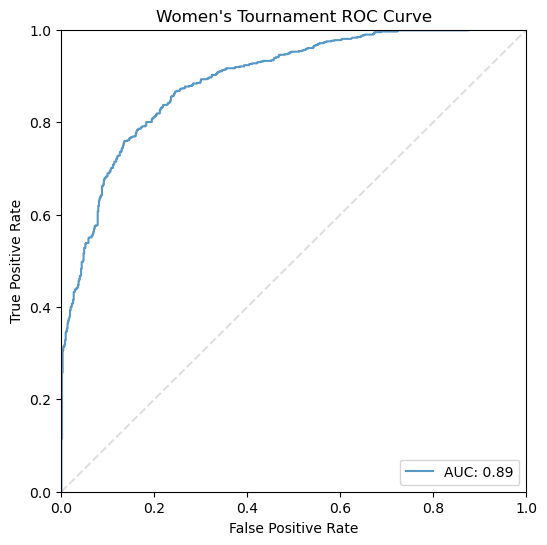

In [17]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(3.5, 3.5), dpi=400)
plt.figure(figsize=(6, 6), dpi=100)

plt.plot(fpr, tpr, label = f"AUC: {auc_value:.2f}", alpha=0.75)
plt.axline([0, 0], [1, 1], color='gray', linestyle='--', alpha=0.25)

plt.title("Women's Tournament ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.show()

In [18]:
from sklearn.metrics import log_loss

print('Out-of-sample log losses by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample log losses by season
2012: 0.3367
2013: 0.4662
2014: 0.3948
2015: 0.3253
2016: 0.5003
2017: 0.4296
2018: 0.4530
2019: 0.3613
2021: 0.3854
2022: 0.4621
2023: 0.4857
2024: 0.3663


In [19]:
print('Out-of-sample Brier scores by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample Brier scores by season
2012: 0.1064
2013: 0.1520
2014: 0.1268
2015: 0.0988
2016: 0.1684
2017: 0.1367
2018: 0.1519
2019: 0.1200
2021: 0.1191
2022: 0.1557
2023: 0.1595
2024: 0.1144


In [20]:
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team A'] == 'LSU'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team B'] == 'LSU'), 'Prediction'] = 0.0001

# print('Out-of-sample Brier scores by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

In [21]:
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team A'] == 'Stanford'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team B'] == 'Stanford'), 'Prediction'] = 0.0001

# print('Out-of-sample log losses by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

In [22]:
def get_bin_sample_sizes(y_prob, n_bins):
    y_prob = pd.Series(y_prob)
    bins = pd.cut(
        y_prob,
        np.linspace(0.0, 1.0, n_bins + 1),
    )

    return np.array([y_prob.loc[(y_prob > bin.left) & (y_prob <= bin.right)].shape[0] for bin in sorted(bins.unique())])

bin_sample_sizes = get_bin_sample_sizes(np.hstack(df_test['Prediction']), 20)

bin_sample_sizes

array([149, 133,  90,  58,  55,  74,  57,  54,  45,  44,  45,  42,  56,
        55,  75,  51,  60,  83, 137, 149])

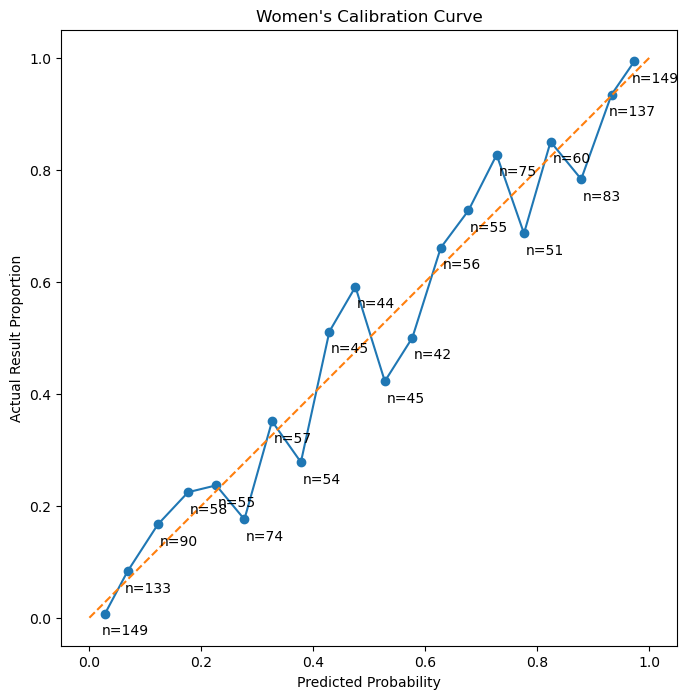

In [23]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    df_test['Result'], 
    df_test['Prediction'], 
    n_bins=20,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(prob_pred, prob_true, marker='o')
ax.plot([0, 1], [0, 1], linestyle='dashed')

for i, (xi, yi, ni) in enumerate(zip(prob_pred, prob_true, bin_sample_sizes)):
    plt.annotate(f'n={ni}', (xi, yi), textcoords='offset points', xytext=(15, -15), ha='center')

ax.set_aspect('equal')

plt.title("Women's Calibration Curve")
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Result Proportion')

plt.show()

In [24]:
df_test['Prediction'].describe()

count    1512.000000
mean        0.499974
std         0.340913
min         0.010272
25%         0.157836
50%         0.494437
75%         0.840405
max         0.990329
Name: Prediction, dtype: float64

In [25]:
# convert results to 0/1 instead of -1/1 for this analysis
((df_test['Result'] + 1)/2 - df_test['Prediction']).abs().describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4)

count    1512.0000
mean        0.2680
std         0.2497
min         0.0097
1%          0.0149
5%          0.0226
25%         0.0559
50%         0.1861
75%         0.3992
95%         0.8023
99%         0.9103
max         0.9735
dtype: float64

In [26]:
df_test.loc[((df_test['Result'] + 1)/2 - df_test['Prediction']).abs() > 0.90, :]

,Season,Result,Team A ID,Team A,Team B ID,Team B,Seed,Head to Head,Past Year Tournament Result,Past 4 Years Tournament Results,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,OS Rating,Team A Efficiency Margin,Team B Efficiency Margin,Prediction
123,2017,1,3280,Mississippi St,3163,Connecticut,1,NaN,-4.0,-5.750000,-0.412850,-0.497594,-2.557918,-0.189880,-0.136550,0.053331,-8.284634,0.411794,0.601674,0.097523
554,2013,1,3208,Georgia,3390,Stanford,3,NaN,-4.0,-2.250000,-0.217909,-0.277231,-2.687332,-0.153412,-0.134997,0.018416,-8.927956,0.252515,0.405927,0.080722
557,2013,1,3257,Louisville,3124,Baylor,4,NaN,-5.0,-2.750000,-0.306015,-0.173513,-2.731550,-0.227979,-0.123222,0.104757,-16.640854,0.319770,0.547749,0.028215
614,2016,1,3449,Washington,3268,Maryland,5,NaN,-4.0,-4.000000,-0.161283,-0.231100,-1.167122,-0.180404,-0.114703,0.065701,-9.485734,0.249110,0.429513,0.064280
615,2016,1,3390,Stanford,3323,Notre Dame,3,NaN,-3.0,-1.750000,-0.179703,-0.113930,-2.091870,-0.074148,-0.086082,-0.011934,-9.972805,0.340167,0.414315,0.098158
616,2016,1,3393,Syracuse,3376,South Carolina,3,NaN,-3.0,-2.000000,-0.209680,-0.089275,-2.345101,-0.105411,-0.094295,0.011116,-8.363303,0.293978,0.399389,0.090935
626,2016,1,3333,Oregon St,3124,Baylor,1,NaN,-2.0,-3.500000,-0.083214,-0.287099,-0.293982,-0.085613,-0.076860,0.008753,-5.445517,0.353622,0.439235,0.093328
728,2023,1,3279,Mississippi,3390,Stanford,7,NaN,-4.0,-5.000000,-0.162460,-0.331071,-1.011216,-0.142098,-0.141242,0.000856,-6.900011,0.304226,0.446324,0.081906
736,2023,1,3274,Miami FL,3231,Indiana,8,NaN,-1.0,-1.666667,-0.092497,-0.123711,-1.400865,-0.191915,-0.127656,0.064259,-14.172145,0.240068,0.431984,0.073795
746,2023,1,3326,Ohio St,3163,Connecticut,1,NaN,-3.0,-4.333333,-0.160496,-0.245358,-0.407857,-0.122596,-0.032417,0.090179,-6.726820,0.322652,0.445248,0.081675


### Train Final Model

In [27]:
np.random.seed(22)

val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

X_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

X_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

y_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), 'Result']
)

y_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), 'Result']
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1134, 13), (378, 13), (1134,), (378,))

In [28]:
params = (
    {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 1_000,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
    } |
    study.best_params
)

mod = LGBMClassifier(**params)

mod.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val),
)

LGBMClassifier(early_stopping_round=25, feature_fraction=0.778518753537347,
               lambda_l1=2.096041209255663, lambda_l2=0.24121410842083418,
               learning_rate=0.025864767729102435, max_depth=8, metric='rmse',
               min_child_samples=3,
               monotone_constraints=[-1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1],
               n_estimators=1000, num_leaves=155, random_state=22,
               verbosity=-1)

In [29]:
mod.predict_proba(X_train)[:, 1]

array([0.70504016, 0.95442545, 0.69581641, ..., 0.60994765, 0.12206269,
       0.20089188])

### Feature Insights

In [30]:
import shap

explainer = shap.Explainer(mod, feature_names=X_train.columns, seed=22)

shap_values = explainer(X_train)

shap_values.shape

(1134, 13)

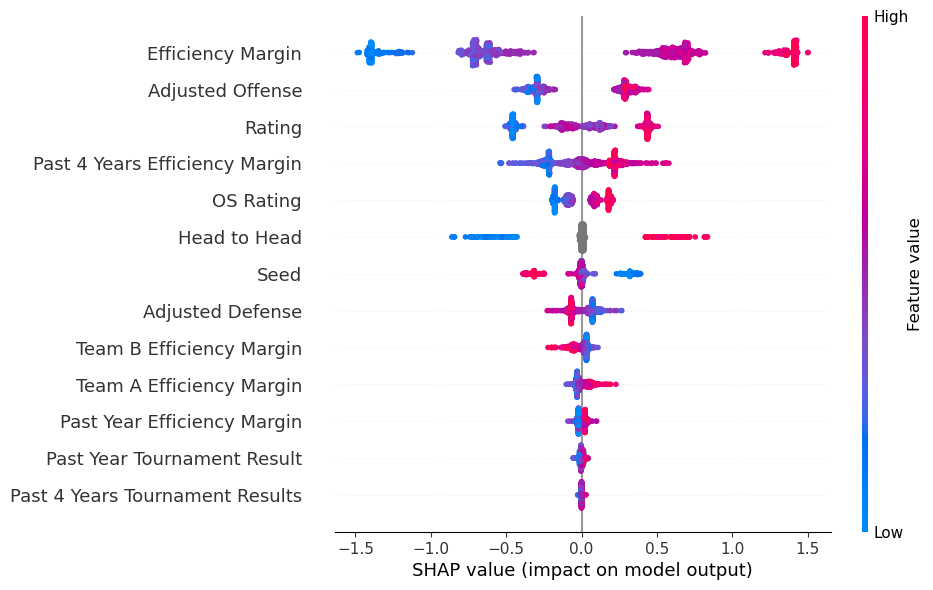

In [31]:
shap.plots.beeswarm(shap_values, max_display=None)

In [32]:
df_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mod.feature_importances_,
}).sort_values(['Importance'], ascending=False, ignore_index=True)

df_feature_importance

,Feature,Importance
0,Past 4 Years Efficiency Margin,259
1,Head to Head,190
2,Team B Efficiency Margin,189
3,Efficiency Margin,178
4,Adjusted Offense,159
5,Team A Efficiency Margin,159
6,Rating,128
7,Seed,124
8,Adjusted Defense,113
9,Past Year Efficiency Margin,102


### Save

In [ ]:
# import pickle

# with open('../data/models/womens/2025_03_15_model.pkl', 'wb') as f:
#     pickle.dump(mod, f)

# df_mod.to_parquet('../data/models/womens/2025_03_15_data.parquet')

# 'Done'

'Done'